In [1]:
import sys
sys.path.append('../../../../../')
%matplotlib inline

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from CADETProcess.reference import ReferenceIO
from CADETProcess.calibration import (
    crop,
    correct_baseline,
    normalize_area,
    correct_baseline_and_normalize,
    fit_polynomial,
    apply_polynomial_calibration,
    apply_beer_lambert,
    deconvolve_extinction,
)

In [3]:
time_full = np.linspace(0, 500, 5001)
signal_full = (40 * np.exp(-0.5 * ((time_full - 200) / 20) ** 2)).reshape(-1, 1)
raw_full = ReferenceIO("UV 280 nm (full run)", time_full, signal_full, flow_rate=1e-6)

# Injection started at t = 60 s; wash step ended at t = 400 s
cropped = crop(raw_full, start=60, end=400)

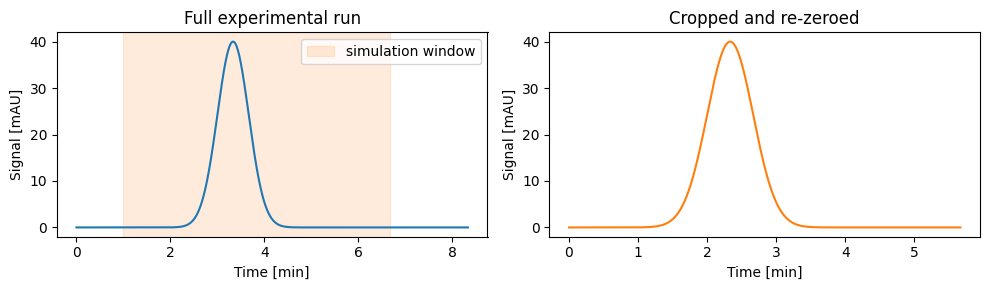

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(time_full / 60, raw_full.solution)
axes[0].axvspan(60 / 60, 400 / 60, alpha=0.15, color="C1", label="simulation window")
axes[0].set_title("Full experimental run")
axes[0].legend()
axes[1].plot(cropped.time / 60, cropped.solution, color="C1")
axes[1].set_title("Cropped and re-zeroed")
for ax in axes:
    ax.set_xlabel("Time [min]")
    ax.set_ylabel("Signal [mAU]")
plt.tight_layout();

In [5]:
time = np.linspace(0, 900, 9001)  # seconds (15 min run)

drift = 5.0 + 0.02 * time  # mAU
ghost = 15 * np.exp(-0.5 * ((time - 120) / 15) ** 2)  # ghost peak at ~2 min
peak  = 80 * np.exp(-0.5 * ((time - 600) / 30) ** 2)  # main peak at ~10 min
signal = (drift + ghost + peak).reshape(-1, 1)

raw = ReferenceIO("UV 280 nm", time, signal, flow_rate=1e-6)
corrected = correct_baseline(raw, threshold=0.05)

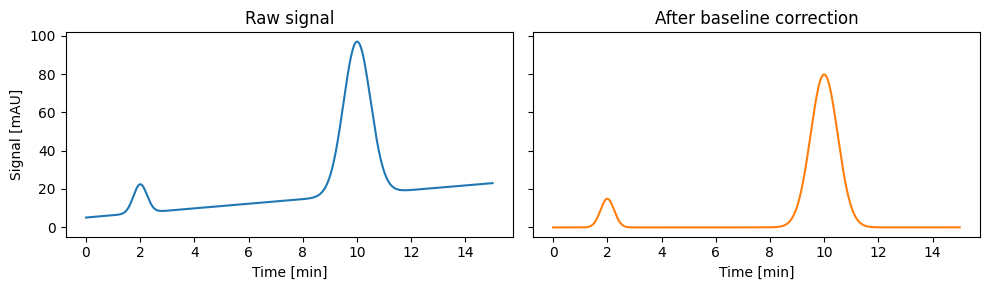

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
axes[0].plot(time / 60, raw.solution)
axes[0].set_title("Raw signal")
axes[1].plot(time / 60, corrected.solution, color="C1")
axes[1].set_title("After baseline correction")
for ax in axes:
    ax.set_xlabel("Time [min]")
axes[0].set_ylabel("Signal [mAU]")
plt.tight_layout();

In [7]:
injected_mass = 5e-9  # mol

normalized = normalize_area(corrected, target_area=injected_mass,
                            start=300, end=900)
normalized_wrong = normalize_area(corrected, target_area=injected_mass)

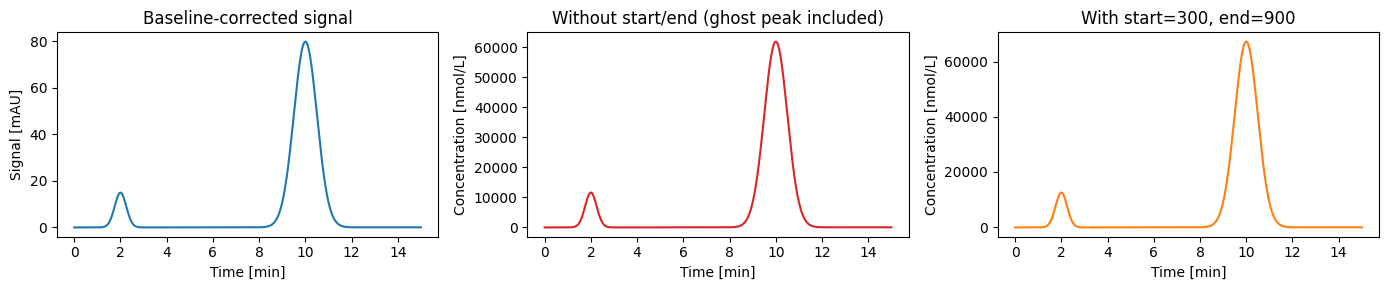

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
axes[0].plot(time / 60, corrected.solution)
axes[0].set_title("Baseline-corrected signal")
axes[0].set_ylabel("Signal [mAU]")
axes[1].plot(time / 60, normalized_wrong.solution * 1e9, color="C3")
axes[1].set_title("Without start/end (ghost peak included)")
axes[1].set_ylabel("Concentration [nmol/L]")
axes[2].plot(time / 60, normalized.solution * 1e9, color="C1")
axes[2].set_title("With start=300, end=900")
axes[2].set_ylabel("Concentration [nmol/L]")
for ax in axes:
    ax.set_xlabel("Time [min]")
plt.tight_layout();

In [9]:
# Extinction coefficient for lysozyme at 280 nm
epsilon = 38_000  # L / (mol·cm)
path_length = 0.2  # cm, typical for analytical UV cells

concentration = apply_beer_lambert(corrected, epsilon, path_length)

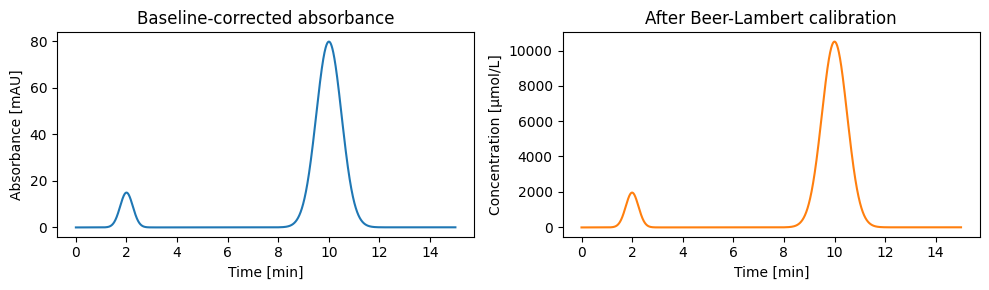

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(time / 60, corrected.solution)
axes[0].set_title("Baseline-corrected absorbance")
axes[0].set_ylabel("Absorbance [mAU]")
axes[1].plot(time / 60, concentration.solution * 1e6, color="C1")
axes[1].set_title("After Beer-Lambert calibration")
axes[1].set_ylabel("Concentration [µmol/L]")
for ax in axes:
    ax.set_xlabel("Time [min]")
plt.tight_layout();

In [11]:
time_dec = np.linspace(0, 600, 6001)

# Extinction matrix: rows = wavelengths (280, 260 nm), columns = components (A, B)
E = np.array([
    [38_000, 5_000],   # ε at 280 nm
    [12_000, 22_000],  # ε at 260 nm
])
path_length = 0.2  # cm

# Simulate two overlapping peaks from known concentrations
c_A = 1e-5 * np.exp(-0.5 * ((time_dec - 200) / 30) ** 2)
c_B = 8e-6 * np.exp(-0.5 * ((time_dec - 400) / 40) ** 2)
A_mat = np.stack([c_A, c_B], axis=1) @ E.T * path_length
ref_280 = ReferenceIO("A280", time_dec, A_mat[:, 0:1], flow_rate=1e-6)
ref_260 = ReferenceIO("A260", time_dec, A_mat[:, 1:2], flow_rate=1e-6)

results = deconvolve_extinction(
    [ref_280, ref_260], E, path_length,
    component_names=["Protein A", "Protein B"],
)

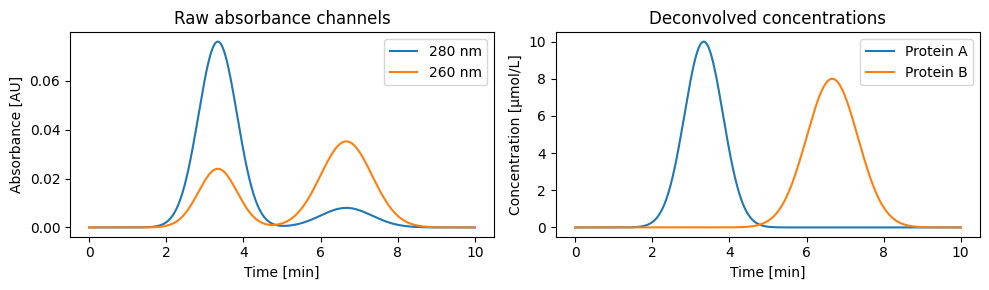

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(time_dec / 60, ref_280.solution, label="280 nm")
axes[0].plot(time_dec / 60, ref_260.solution, label="260 nm")
axes[0].set_title("Raw absorbance channels")
axes[0].legend()
axes[1].plot(time_dec / 60, results[0].solution * 1e6, label="Protein A")
axes[1].plot(time_dec / 60, results[1].solution * 1e6, label="Protein B")
axes[1].set_title("Deconvolved concentrations")
axes[1].legend()
for ax in axes:
    ax.set_xlabel("Time [min]")
axes[0].set_ylabel("Absorbance [AU]")
axes[1].set_ylabel("Concentration [µmol/L]")
plt.tight_layout();

In [13]:
# Standard measurements: conductivity vs. NaCl concentration
conductivity_standards = np.array([0.5, 2.1, 5.3, 10.2, 20.8, 51.3])  # mS/cm
nacl_concentration = np.array([5, 20, 50, 100, 200, 500])  # mmol/L

coeffs, r2 = fit_polynomial(conductivity_standards, nacl_concentration, degree=1)
print(f"R² = {r2:.4f}")

time_cond = np.linspace(0, 600, 6001)
conductivity = (2 + 45 * (1 / (1 + np.exp(-0.05 * (time_cond - 300))))).reshape(-1, 1)
ref_cond = ReferenceIO("Conductivity", time_cond, conductivity, flow_rate=1e-6)

ref_nacl = apply_polynomial_calibration(ref_cond, coeffs)

R² = 1.0000


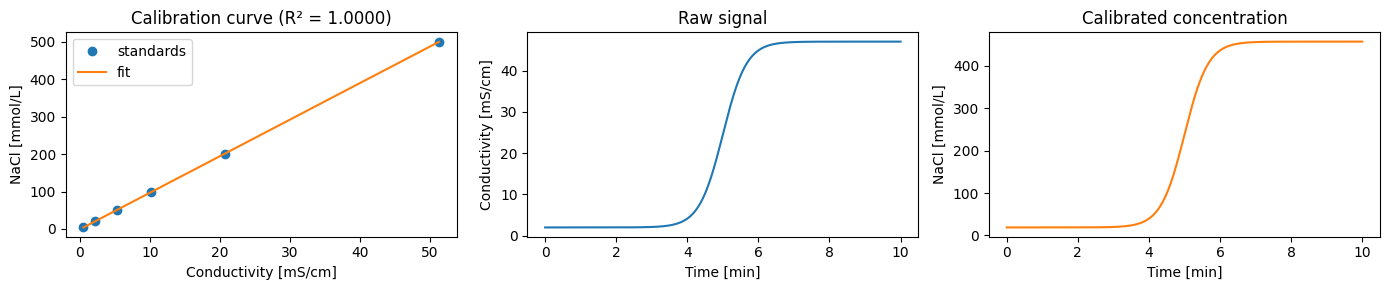

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
axes[0].plot(conductivity_standards, nacl_concentration, "o", label="standards")
axes[0].plot(conductivity_standards, np.polyval(coeffs, conductivity_standards), label="fit")
axes[0].set_xlabel("Conductivity [mS/cm]")
axes[0].set_ylabel("NaCl [mmol/L]")
axes[0].set_title(f"Calibration curve (R² = {r2:.4f})")
axes[0].legend()
axes[1].plot(time_cond / 60, ref_cond.solution)
axes[1].set_xlabel("Time [min]")
axes[1].set_ylabel("Conductivity [mS/cm]")
axes[1].set_title("Raw signal")
axes[2].plot(time_cond / 60, ref_nacl.solution, color="C1")
axes[2].set_xlabel("Time [min]")
axes[2].set_ylabel("NaCl [mmol/L]")
axes[2].set_title("Calibrated concentration")
plt.tight_layout();